# Water Potability Classification — Exploratory Data Analysis

Predict whether a water sample is safe to drink (Potable = 1) from 9 chemical/physical measurements (pH, Hardness, Solids, Chloramines, Sulfate, Conductivity, Organic carbon, Trihalomethanes, Turbidity). 3,276 samples, ~39% potable.

**Target:** `Potability` (0 = Not Potable, 1 = Potable)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/water_potability.csv')

print('Shape:', df.shape)
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (3276, 10)

Dtypes:
float64    9
int64      1
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicate rows: 0
Memory (MB): 0.25


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No explicit NaN values')

                 Missing  Percent
Sulfate              781    23.84
ph                   491    14.99
Trihalomethanes      162     4.95


## 4. Target Variable Distribution

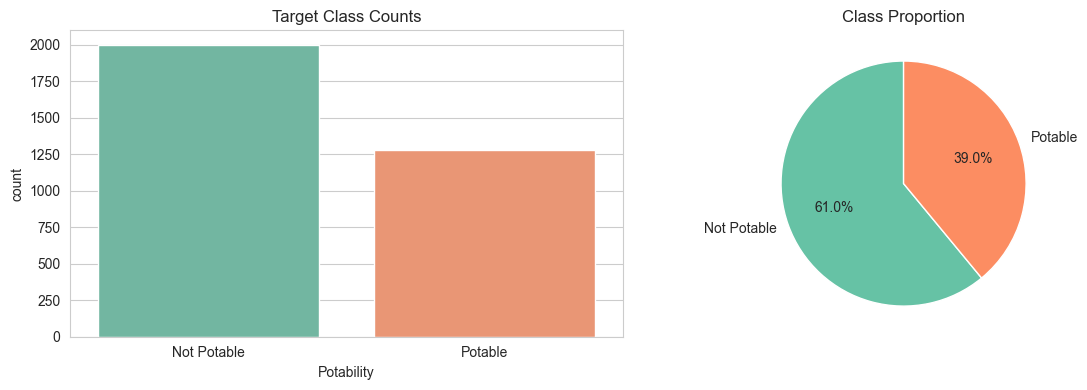


Class balance (%):
Potability
0    60.99
1    39.01
Name: count, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['Potability'].value_counts().sort_index()
sns.countplot(x='Potability', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Counts')
axes[0].set_xticklabels(['Not Potable', 'Potable'])
axes[1].pie(target_counts, labels=['Not Potable', 'Potable'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()
print('\nClass balance (%):')
print((target_counts / target_counts.sum() * 100).round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Potability' in numeric_cols:
    numeric_cols.remove('Potability')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols)

Numeric features (9):
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


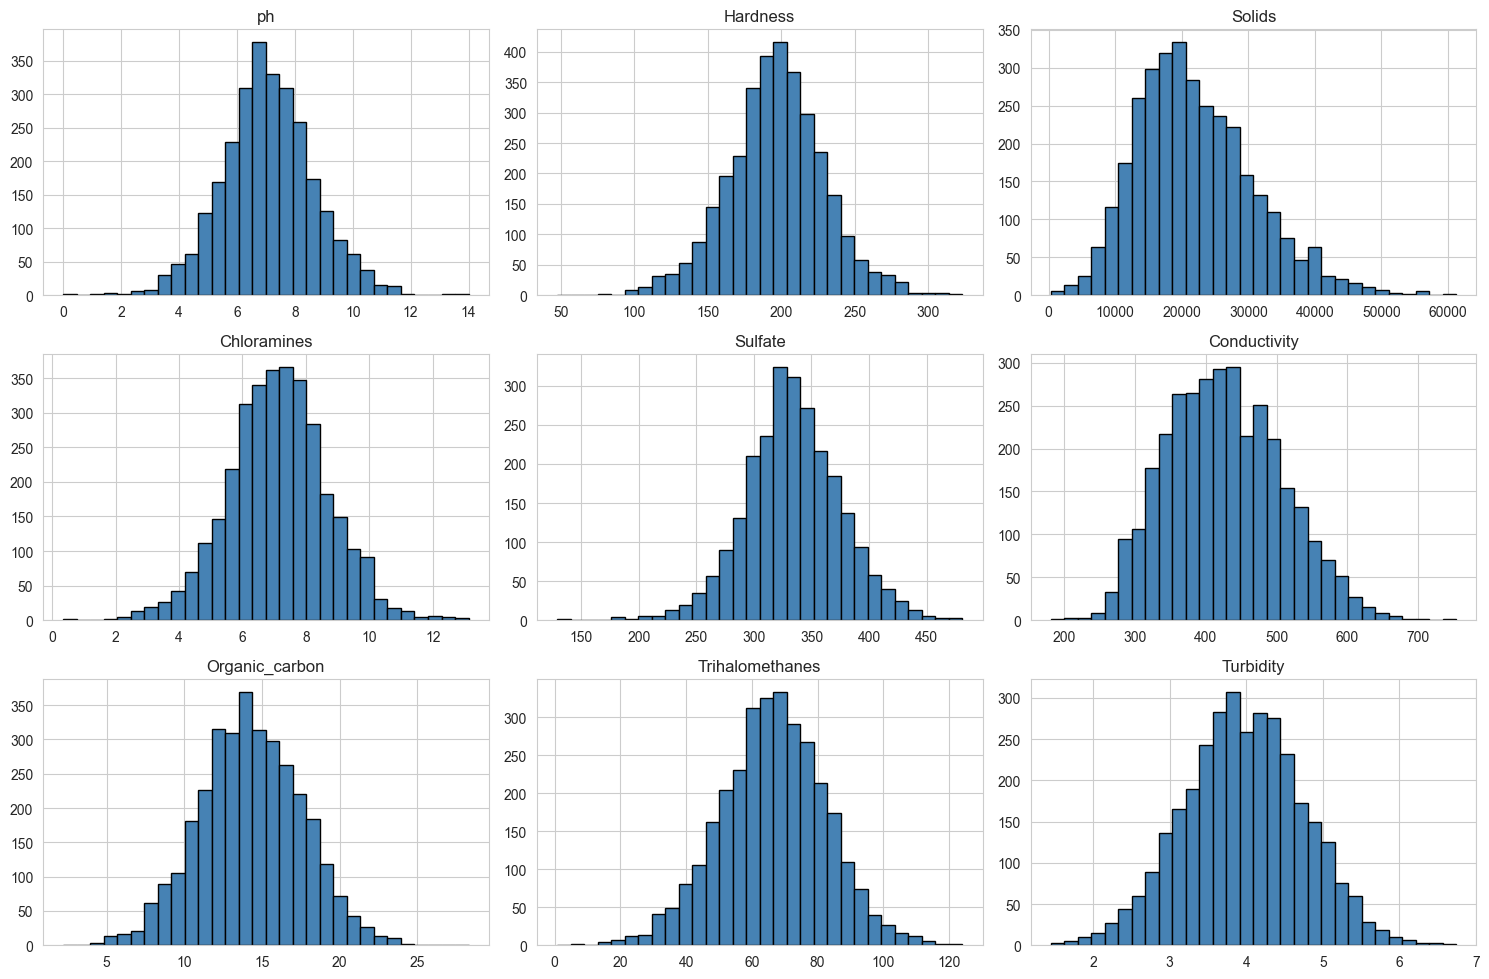

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

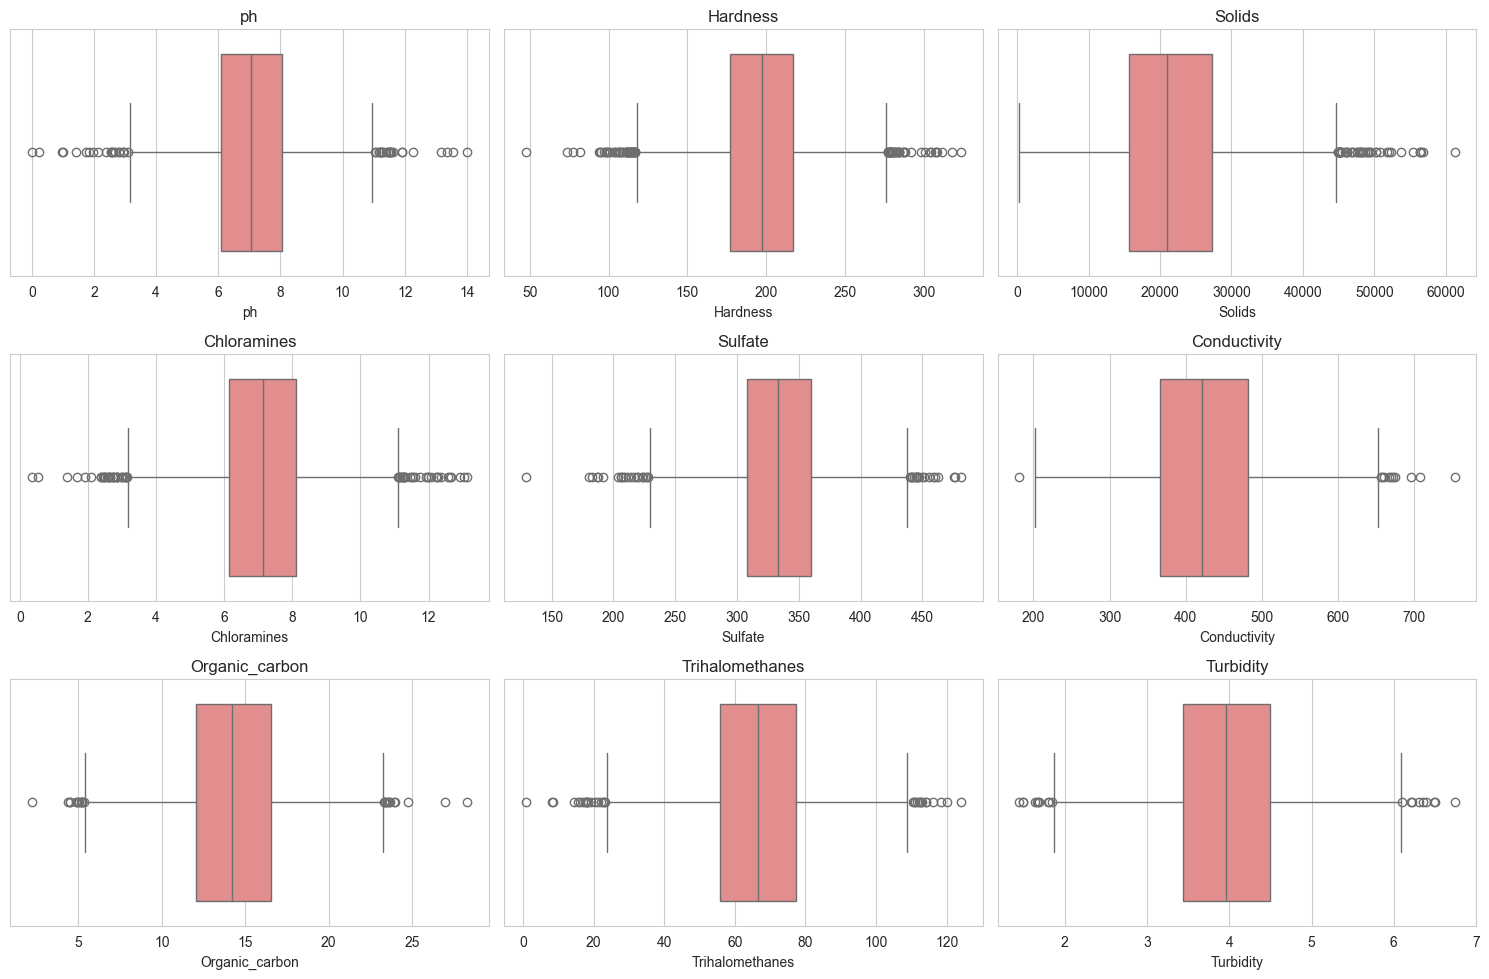

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [11]:
corrs_all = df[numeric_cols + ['Potability']].corr()['Potability'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'Potability'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
Solids            0.034
Organic_carbon    0.030
Chloramines       0.024
Sulfate           0.024
Hardness          0.014
Conductivity      0.008
Name: Potability, dtype: float64


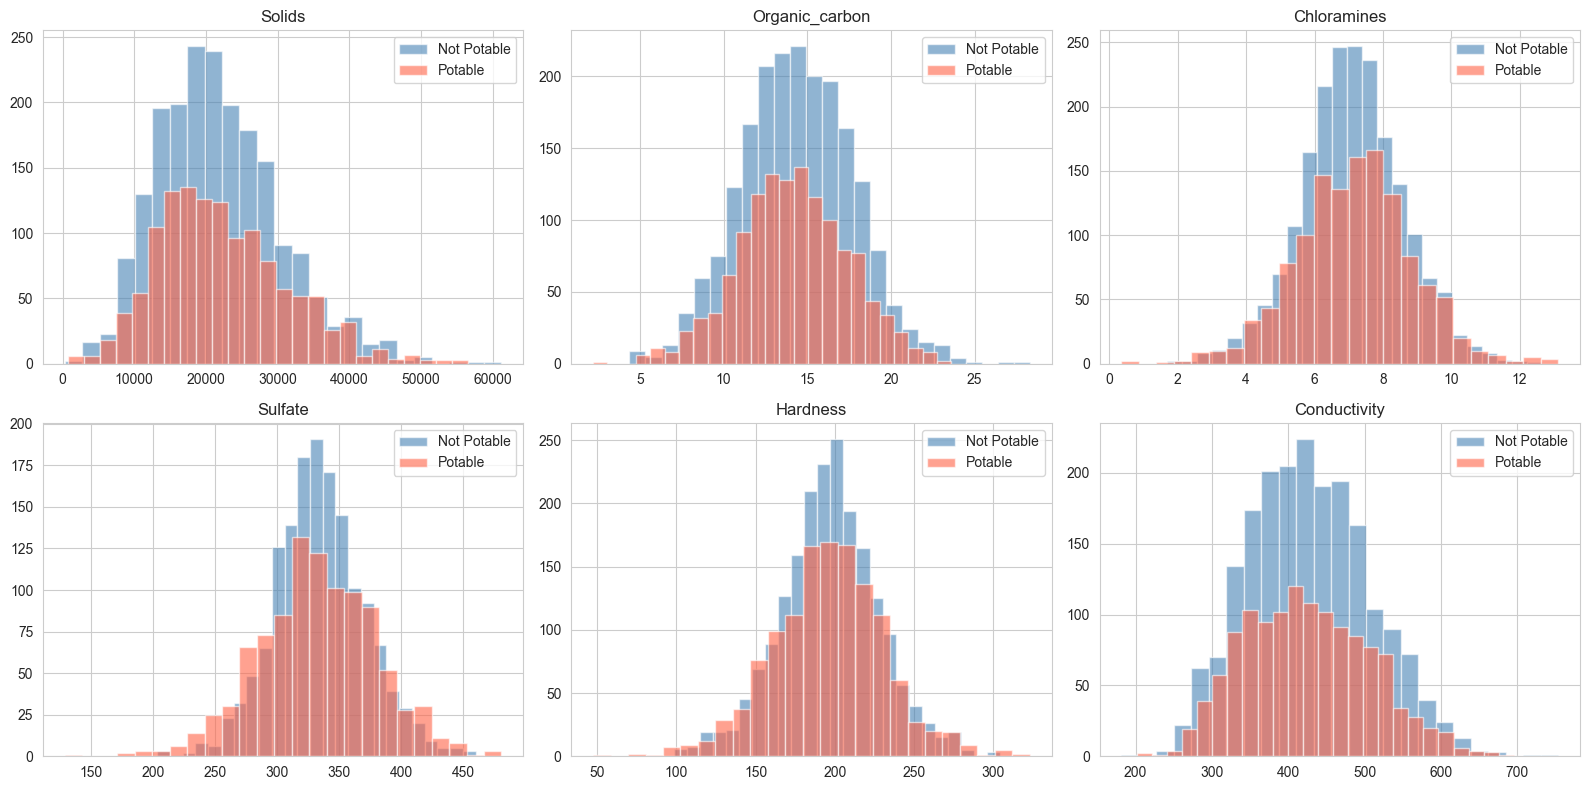

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['Not Potable', 'Potable']
colors = ['steelblue', 'tomato']
for i, col in enumerate(top_features[:6]):
    for cls, lbl, c in [(0, labels[0], colors[0]), (1, labels[1], colors[1])]:
        axes[i].hist(df[df['Potability']==cls][col].dropna(), bins=25, alpha=0.6, label=lbl, color=c)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [13]:
means = df.groupby('Potability')[numeric_cols].mean().T
means.columns = ['Not Potable', 'Potable']
means['Difference'] = means.iloc[:, 1] - means.iloc[:, 0]
means.sort_values('Difference', key=abs, ascending=False).round(3).head(15)

,Not Potable,Potable,Difference
Solids,21777.491,22383.991,606.500
Sulfate,334.564,332.567,-1.997
Conductivity,426.730,425.384,-1.347
Hardness,196.733,195.801,-0.933
Trihalomethanes,66.304,66.540,0.236
Organic_carbon,14.364,14.161,-0.203
Chloramines,7.092,7.169,0.077
ph,7.085,7.074,-0.012
Turbidity,3.966,3.968,0.003


## 7. Correlation Analysis

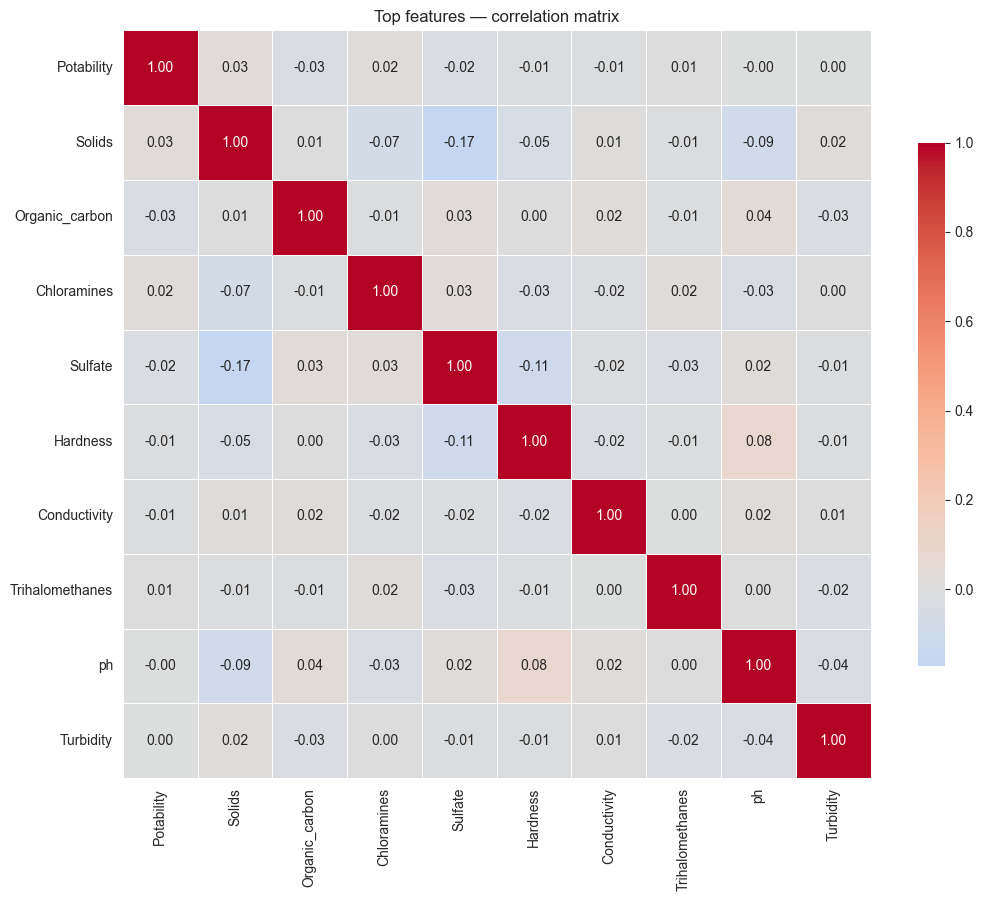

In [14]:
# Restrict to top numeric features for legibility
top_numeric = corrs_all.head(15).index.tolist()
if 'Potability' not in top_numeric:
    top_numeric.append('Potability')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

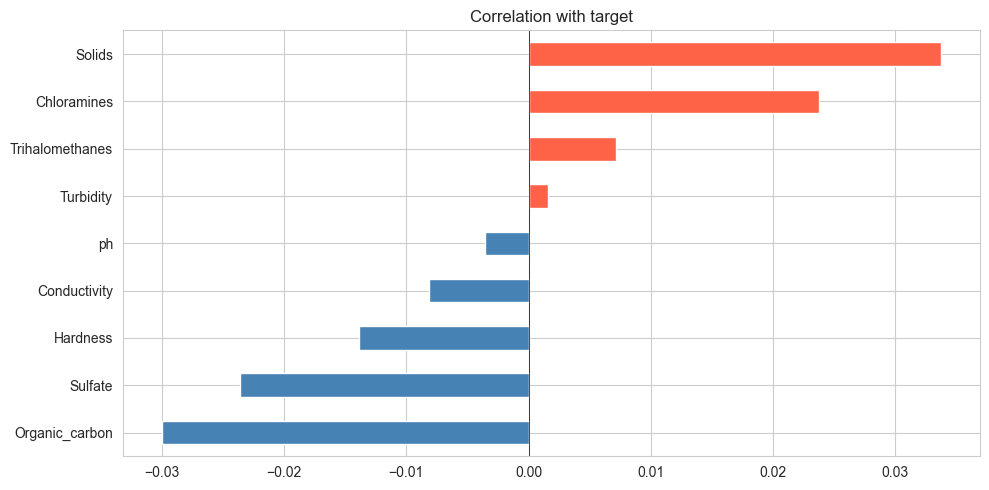

In [15]:
target_corr = df[numeric_cols + ['Potability']].corr()['Potability'].drop('Potability').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Drinking-Water Safety Thresholds

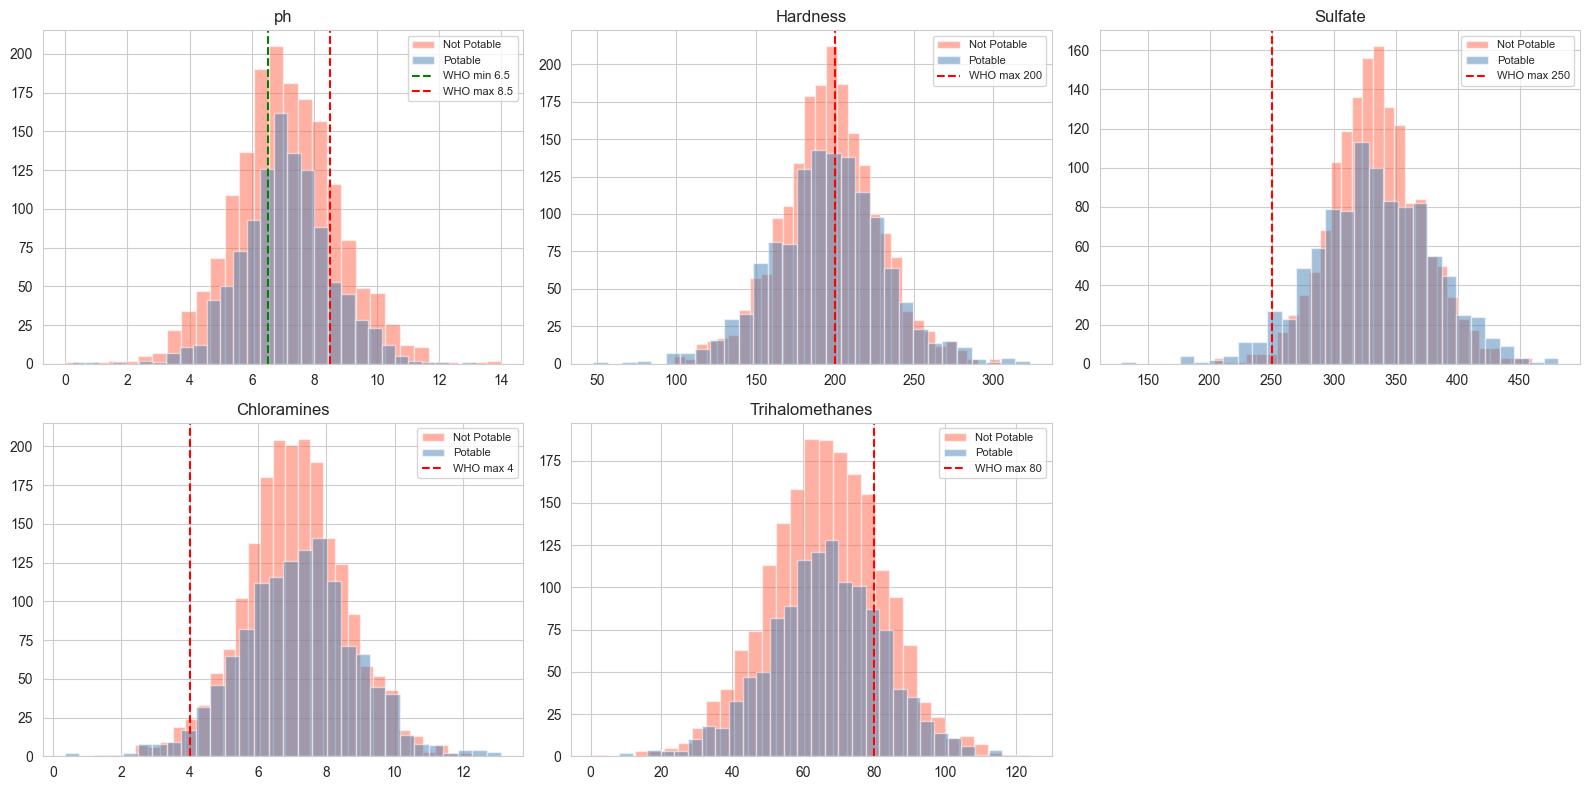

In [16]:
# WHO drinking-water guidelines (rough indicative values)
thresholds = {'ph': (6.5, 8.5), 'Hardness': (None, 200), 'Sulfate': (None, 250),
              'Chloramines': (None, 4), 'Trihalomethanes': (None, 80)}
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, (col, (lo, hi)) in enumerate(thresholds.items()):
    if i >= 6: break
    for cls, lbl, c in [(0, 'Not Potable', 'tomato'), (1, 'Potable', 'steelblue')]:
        axes[i].hist(df[df['Potability']==cls][col].dropna(), bins=30, alpha=0.5, label=lbl, color=c)
    if lo is not None: axes[i].axvline(lo, color='green', linestyle='--', label=f'WHO min {lo}')
    if hi is not None: axes[i].axvline(hi, color='red',   linestyle='--', label=f'WHO max {hi}')
    axes[i].set_title(col); axes[i].legend(fontsize=8)
axes[5].axis('off')
plt.tight_layout(); plt.show()

In [17]:
# Even within potable samples, many violate WHO ranges — feature distributions overlap heavily
# This is part of why the problem is hard.
violations = pd.DataFrame({
    'pH out of [6.5, 8.5]': ((df['ph'] < 6.5) | (df['ph'] > 8.5)).sum(),
    'Chloramines > 4': (df['Chloramines'] > 4).sum(),
    'Sulfate > 250': (df['Sulfate'] > 250).sum(),
    'Trihalomethanes > 80': (df['Trihalomethanes'] > 80).sum(),
}, index=['count']).T
violations['percent'] = (violations['count'] / len(df) * 100).round(1)
violations

,count,percent
"pH out of [6.5, 8.5]",1457,44.5
Chloramines > 4,3187,97.3
Sulfate > 250,2437,74.4
Trihalomethanes > 80,602,18.4


## 9. Pair Plot of Top Features

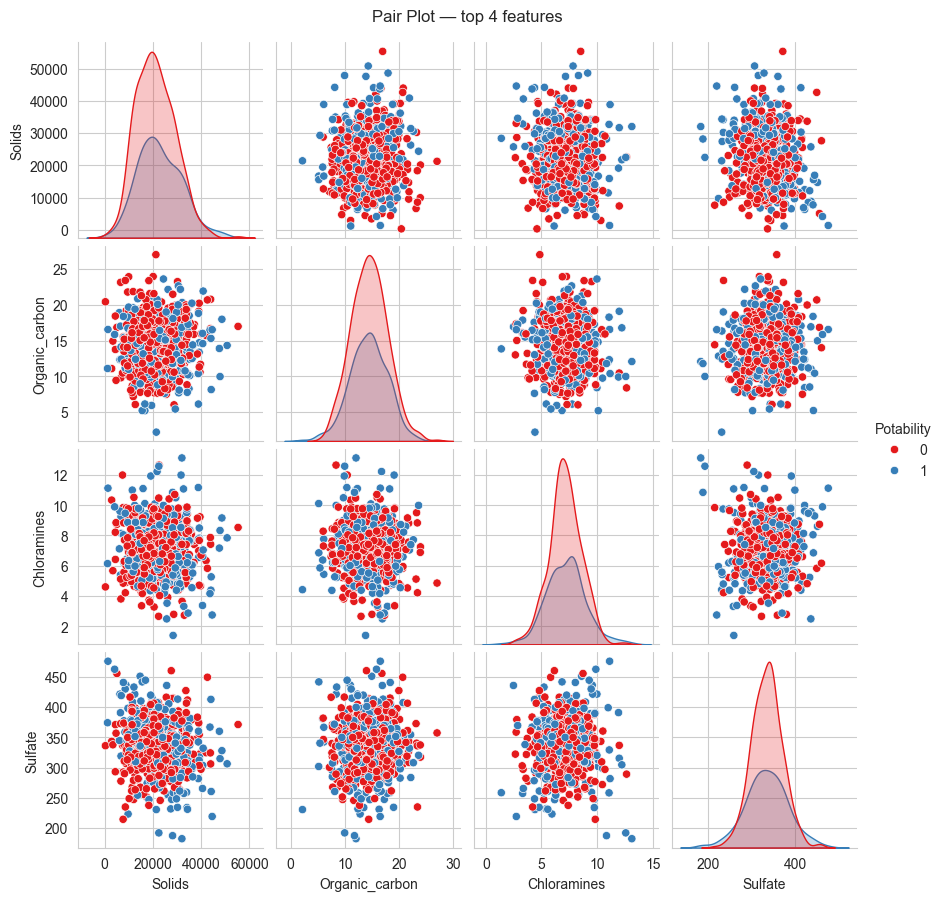

In [18]:
sample = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['Potability']].dropna(),
             hue='Potability', palette='Set1', diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [19]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Class 0 count', 'Class 1 count',
               'Class imbalance ratio', 'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df),
        df.shape[1] - 1,
        int((df['Potability'] == 0).sum()),
        int((df['Potability'] == 1).sum()),
        f"{(df['Potability'] == 0).sum() / max(1, (df['Potability'] == 1).sum()):.2f}:1",
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,3276
1,Total features,9
2,Class 0 count,1998
3,Class 1 count,1278
4,Class imbalance ratio,1.56:1
5,Top correlated feature,Solids
6,Top correlation value,0.034
